In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loanData=pd.read_csv('loan_data_set.csv')
loanData

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
loanData.head(5).T

,0,1,2,3,4
Loan_ID,LP001002,LP001003,LP001005,LP001006,LP001008
Gender,Male,Male,Male,Male,Male
Married,No,Yes,Yes,Yes,No
Dependents,0,1,0,0,0
Education,Graduate,Graduate,Graduate,Not Graduate,Graduate
Self_Employed,No,No,Yes,No,No
ApplicantIncome,5849,4583,3000,2583,6000
CoapplicantIncome,0.0,1508.0,0.0,2358.0,0.0
LoanAmount,NaN,128.0,66.0,120.0,141.0
Loan_Amount_Term,360.0,360.0,360.0,360.0,360.0


In [4]:
loanData.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [5]:
loanData.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [6]:
loanData.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


In [7]:
loanData['Gender']=loanData['Gender'].str.capitalize()
loanData['Married']=loanData['Married'].str.capitalize()
loanData['Education']=loanData['Education'].str.capitalize()
loanData['Self_Employed']=loanData['Self_Employed'].str.capitalize()
loanData['Property_Area']=loanData['Property_Area'].str.capitalize()
loanData['Loan_Status']=loanData['Loan_Status'].str.capitalize()
loanData.head(10).T

,0,1,2,3,4,5,6,7,8,9
Loan_ID,LP001002,LP001003,LP001005,LP001006,LP001008,LP001011,LP001013,LP001014,LP001018,LP001020
Gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
Married,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes
Dependents,0,1,0,0,0,2,0,3+,2,1
Education,Graduate,Graduate,Graduate,Not graduate,Graduate,Graduate,Not graduate,Graduate,Graduate,Graduate
Self_Employed,No,No,Yes,No,No,Yes,No,No,No,No
ApplicantIncome,5849,4583,3000,2583,6000,5417,2333,3036,4006,12841
CoapplicantIncome,0.0,1508.0,0.0,2358.0,0.0,4196.0,1516.0,2504.0,1526.0,10968.0
LoanAmount,NaN,128.0,66.0,120.0,141.0,267.0,95.0,158.0,168.0,349.0
Loan_Amount_Term,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0,360.0


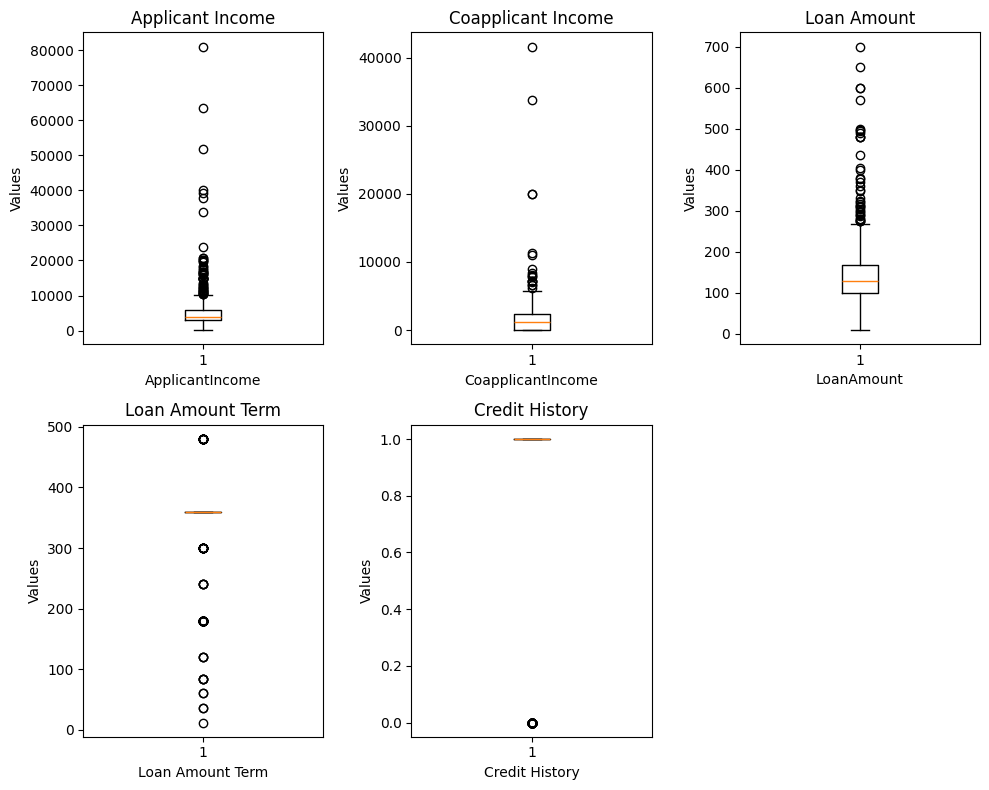

In [8]:

plt.figure(figsize=(10, 8))

cols = ['ApplicantIncome',
        'CoapplicantIncome',
        'LoanAmount',
        'Loan_Amount_Term',
        'Credit_History']

titles = ["Applicant Income",
          "Coapplicant Income",
          "Loan Amount",
          "Loan Amount Term",
          "Credit History"]

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(loanData[col].dropna())
    plt.xlabel(col.replace('_', ' '))
    plt.ylabel("Values")
    plt.title(titles[i-1])

plt.tight_layout()
plt.show()



In [10]:
print(loanData.duplicated().sum())

0


In [11]:
loanData = loanData.copy()

In [12]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed']

for col in categorical_cols:
    loanData[col] = loanData[col].fillna(loanData[col].mode()[0])

In [13]:
numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in numerical_cols:
    loanData[col] = loanData[col].fillna(loanData[col].median())

In [14]:
loanData['Credit_History'] = loanData['Credit_History'].fillna(
    loanData['Credit_History'].mode()[0]
)

In [15]:
loanData.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

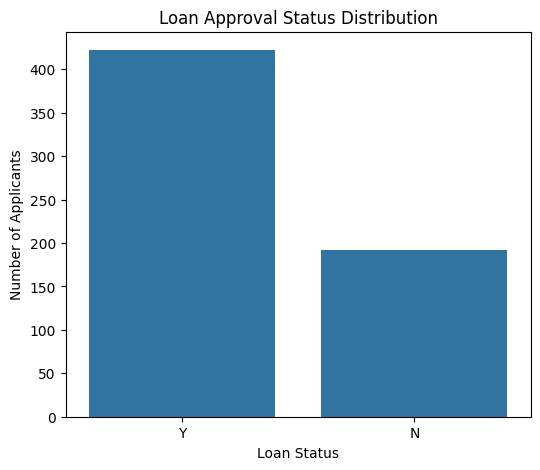

In [16]:
plt.figure(figsize=(6, 5))

sns.countplot(data=loanData, x='Loan_Status')

plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.title("Loan Approval Status Distribution")

plt.show()


In [24]:
#Simple insight:Most applicants in the dataset are eligible for the loan, while fewer applicants are not eligible.

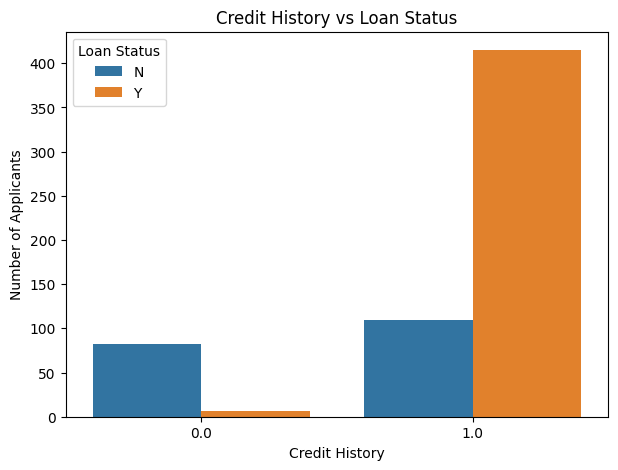

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=loanData, x='Credit_History', hue='Loan_Status')

plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.title("Credit History vs Loan Status")

plt.legend(title="Loan Status")

plt.show()

In [25]:
#Simple insight:Applicants with a positive credit history are more likely to get their loans approved.

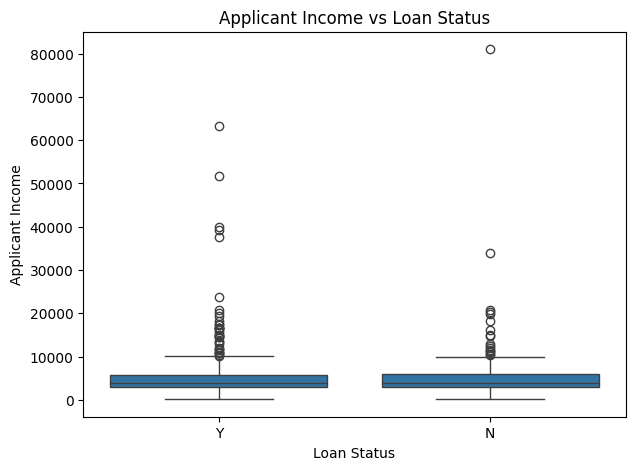

In [18]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=loanData, x='Loan_Status', y='ApplicantIncome')

plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.title("Applicant Income vs Loan Status")

plt.show()

In [26]:
#Simple insight:Approved and rejected applicants have some overlap in income, so income alone does not determine loan eligibility.

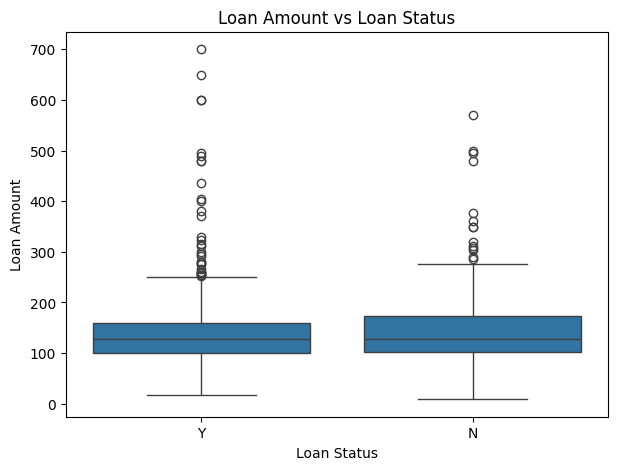

In [19]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=loanData, x='Loan_Status', y='LoanAmount')

plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.title("Loan Amount vs Loan Status")

plt.show()

In [27]:
#Simple insight:Loan amounts vary in both approved and rejected groups, with some extreme values.

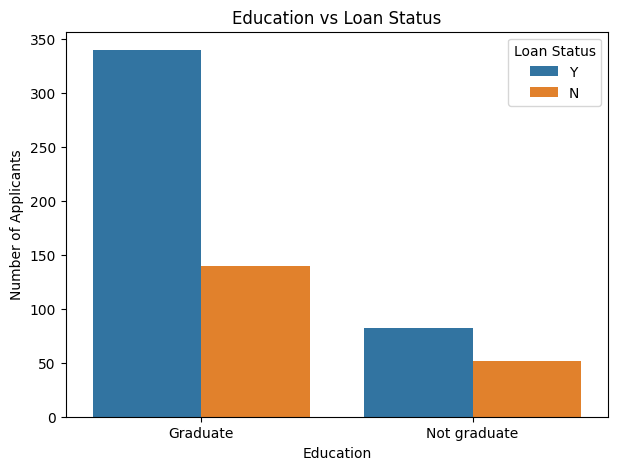

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(data=loanData, x='Education', hue='Loan_Status')

plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.title("Education vs Loan Status")

plt.legend(title="Loan Status")

plt.show()

In [28]:
#Simple insight:Graduates generally have more approved applications than non-graduates.

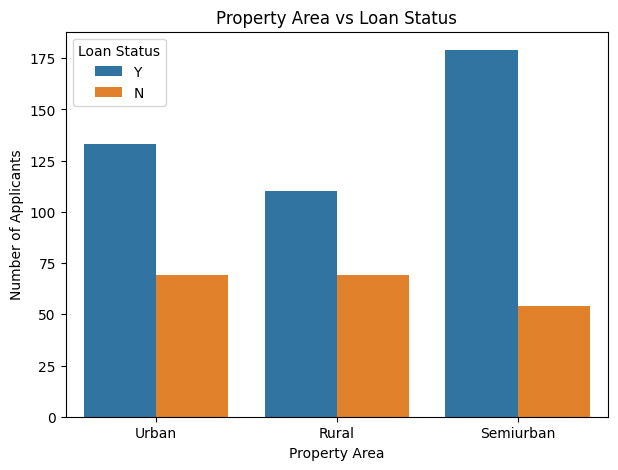

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(data=loanData, x='Property_Area', hue='Loan_Status')

plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.title("Property Area vs Loan Status")

plt.legend(title="Loan Status")

plt.show()

In [29]:
#Simple insight:Applicants from different property areas have different loan approval patterns.

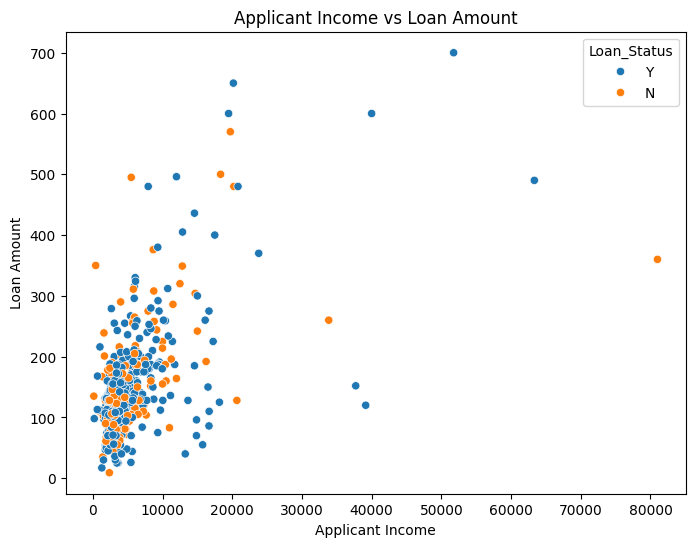

In [22]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=loanData,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status'
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Applicant Income vs Loan Amount")

plt.show()

In [30]:
#Simple insight:There is some relationship between applicant income and the loan amount requested, but it is not perfectly linear.

In [31]:
loan_encoded = loanData.copy()

# Mapping all categorical columns

loan_encoded['Gender'] = loanData['Gender'].map({'Female': 0, 'Male': 1})

loan_encoded['Married'] = loanData['Married'].map({'No': 0, 'Yes': 1})

loan_encoded['Dependents'] = loanData['Dependents'].map({
    '0': 0,
    '1': 1,
    '2': 2,
    '3+': 3
})

loan_encoded['Education'] = loanData['Education'].map({
    'Not Graduate': 0,
    'Graduate': 1
})

loan_encoded['Self_Employed'] = loanData['Self_Employed'].map({
    'No': 0,
    'Yes': 1
})

loan_encoded['Property_Area'] = loanData['Property_Area'].map({
    'Rural': 0,
    'Semiurban': 1,
    'Urban': 2
})

loan_encoded['Loan_Status'] = loanData['Loan_Status'].map({
    'N': 0,
    'Y': 1
})

In [32]:
loan_encoded.drop('Loan_ID', axis=1, inplace=True)

In [33]:
loan_encoded.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1.0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1.0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1.0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,NaN,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,1.0,0,6000,0.0,141.0,360.0,1.0,2,1


In [34]:
loan_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          480 non-null    float64
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 57.7 KB


In [35]:
loanData['Education'].unique()

<ArrowStringArray>
['Graduate', 'Not graduate']
Length: 2, dtype: str

In [36]:
loan_encoded['Education'].unique()

array([ 1., nan])

In [37]:
loan_encoded['Education'] = loanData['Education'].map({
    'Not graduate': 0,
    'Graduate': 1
})

In [38]:
loan_encoded['Education'].unique()

array([1, 0])

In [39]:
loan_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


In [40]:
loan_encoded.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [41]:
X = loan_encoded.drop('Loan_Status', axis=1)
y = loan_encoded['Loan_Status']

In [42]:
print(X.shape)
print(y.shape)

(614, 11)
(614,)


C:\Users\Seema\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📊 MODEL PERFORMANCE
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1 Score: 0.9081081081081082


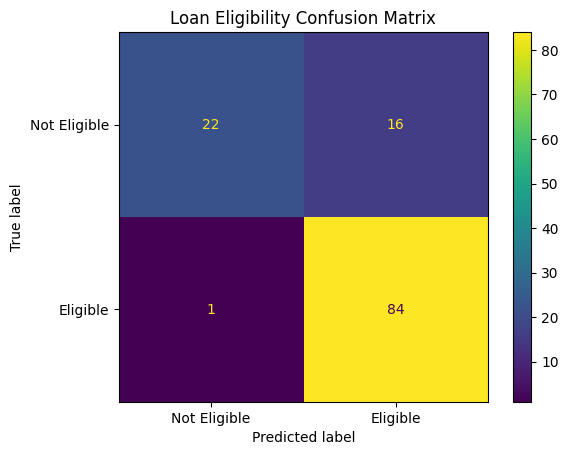


✅ Model saved successfully!


In [43]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib


# =========================
# DEFINE X AND y
# =========================

X = loan_encoded.drop('Loan_Status', axis=1)
y = loan_encoded['Loan_Status']


# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# MODEL
# =========================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


# =========================
# PREDICTION
# =========================

y_pred = model.predict(X_test)


# =========================
# METRICS
# =========================

print("📊 MODEL PERFORMANCE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Eligible', 'Eligible']
)

disp.plot()

plt.title("Loan Eligibility Confusion Matrix")
plt.show()


# =========================
# SAVE MODEL
# =========================

joblib.dump(model, "loan_model.pkl")
joblib.dump(X.columns.tolist(), "loan_model_columns.pkl")

print("\n✅ Model saved successfully!")